In [ ]:
import os
from pathlib import Path
# Resolve submission_partition_draft root from common launch locations.
def _resolve_partition_root():
    cwd = Path(os.getcwd()).resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "primary_script").exists() and (p / "intermediate").exists():
            return p
        candidate = p / "technical_review" / "submission_partition_draft"
        if (candidate / "primary_script").exists():
            return candidate
    raise RuntimeError("Could not locate submission_partition_draft root")
REPO_ROOT = _resolve_partition_root()


In [1]:
#print('Scanpy version:', sc.__version__)

In [2]:
#!pip install --upgrade scan

In [3]:
#print('PyNNDescent version:', pynndescent.__version__)

In [4]:
#import pynndescent

In [5]:
#!pip install --upgrade pynndescent

In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import scvi
import torch
import warnings
import leidenalg as la
from matplotlib import pyplot as plt
from matplotlib.pyplot import rc_context
from scvi.autotune import ModelTuner
from ray import tune
from scipy.io import mmwrite

In [7]:
os.makedirs(str(REPO_ROOT / 'intermediate' / 'pbmc'), exist_ok=True)
os.makedirs(str(REPO_ROOT / 'intermediate' / 'adipose'), exist_ok=True)

mkdir: cannot create directory ‘/media/MPEdge16/MM137/sc/py/py_out/pbmc’: File exists
mkdir: cannot create directory ‘/media/MPEdge16/MM137/sc/py/py_out/adipose’: File exists


In [8]:
warnings.filterwarnings('ignore')
sc.set_figure_params(dpi=200)
plt.rcParams['figure.figsize'] = [3,3]

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [10]:
os.chdir(str(REPO_ROOT / 'intermediate'))

In [4]:
adata = sc.read_h5ad("mm_pbmc.h5ad")

In [8]:
np.all(adata.X.data == adata.X.data.astype(np.int32))

True

In [7]:
sc.pp.filter_cells(adata, min_genes = 200)
sc.pp.filter_genes(adata, min_cells = 10)
adata.var['MT'] = adata.var_names.str.startswith('MT-')
adata = adata[adata.obs.percent_mito <= 10]

In [8]:
adata.layers['counts'] = adata.X.copy()

In [9]:
sc.pp.normalize_total(adata, target_sum = 1e4)
sc.pp.log1p(adata)
adata.raw = adata

In [10]:
sc.pp.highly_variable_genes(adata, n_top_genes=5000, subset = False, layer = 'counts', 
                            flavor = "seurat_v3", batch_key="lane")

In [11]:
adata_var = adata.var
csv_data = pd.read_csv(str(REPO_ROOT / 'primary_dependents' / 'EXCLUDE_XY_TCR_IG.csv'), header = None)

positions = np.where(adata.var_names.isin(csv_data[0]))[0]
adata.var.iloc[positions, adata.var.columns.get_loc('highly_variable')] = False
adata.var.loc[adata.var.index=="TRAV1-2", "highly_variable"] = True # force TRAV1-2 to be hvg; MAIT marker
adata.var['highly_variable'].value_counts()

highly_variable
False    19754
True      4518
Name: count, dtype: int64

In [12]:
model_cls = scvi.model.SCVI
model_cls.setup_anndata(adata = adata, layer = "counts", batch_key = 'lane', 
                        categorical_covariate_keys=['study_id'], 
                        continuous_covariate_keys=['percent_mito', 'nCount_RNA'])
tuner = ModelTuner(model_cls)

In [13]:
tuner.info()

ModelTuner registry for SCVI

                  Tunable hyperparameters                  
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃      Hyperparameter      ┃ Default value ┃    Source    ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│         n_hidden         │      128      │     VAE      │
│         n_latent         │      10       │     VAE      │
│         n_layers         │       1       │     VAE      │
│       dropout_rate       │      0.1      │     VAE      │
│        dispersion        │     gene      │     VAE      │
│     log_variational      │     True      │     VAE      │
│     gene_likelihood      │     zinb      │     VAE      │
│   latent_distribution    │    normal     │     VAE      │
│    encode_covariates     │     False     │     VAE      │
│ deeply_inject_covariates │     True      │     VAE      │
│      use_batch_norm      │     both      │     VAE      │
│      use_layer_norm      │     none      │     VAE      │
│  use_observed_lib_size   │     True      │     VAE      │
│      var_activation      │     None      │     VAE      │
│        optimizer         │     Adam      │ TrainingPlan │
│            lr            │     0.001     │ TrainingPlan │
│       weight_decay       │     1e-06     │ TrainingPlan │
│           eps            │     0.01      │ TrainingPlan │
│    n_steps_kl_warmup     │     None      │ TrainingPlan │
│    n_epochs_kl_warmup    │      400      │ TrainingPlan │
│   reduce_lr_on_plateau   │     False     │ TrainingPlan │
│        lr_factor         │      0.6      │ TrainingPlan │
│       lr_patience        │      30       │ TrainingPlan │
│       lr_threshold       │      0.0      │ TrainingPlan │
│          lr_min          │       0       │ TrainingPlan │
│      max_kl_weight       │      1.0      │ TrainingPlan │
│      min_kl_weight       │      0.0      │ TrainingPlan │
│        batch_size        │      128      │     SCVI     │
└──────────────────────────┴───────────────┴──────────────┘

       Available metrics        
┏━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃     Metric      ┃    Mode    ┃
┡━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ validation_loss │    min     │
└─────────────────┴────────────┘

                         Default search space                         
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Hyperparameter ┃ Sample function ┃  Arguments  ┃ Keyword arguments ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│    n_hidden    │     choice      │ [[64, 128]] │        {}         │
└────────────────┴─────────────────┴─────────────┴───────────────────┘

In [14]:
search_space = {
    "n_hidden": tune.choice([92, 128, 192, 256]),
    "n_latent": tune.choice([10, 20, 30, 40, 50, 60]),
    "n_layers": tune.choice([1, 2, 3]),
    "lr": tune.loguniform(1e-4, 1e-2),
    "gene_likelihood": tune.choice(["nb", "zinb"])}

In [15]:
results = tuner.fit(adata, metric="validation_loss",
                    resources = {'gpu': 1}, 
                    search_space = search_space,
                    num_samples = 100,
                    max_epochs = 20)

2024-09-05 06:53:41,648	INFO worker.py:1749 -- Started a local Ray instance.
2024-09-05 06:53:44,199	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `Tuner(...)`.
2024-09-05 06:53:44,202	INFO tune.py:614 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949
(_trainable pid=1772418) /media/MPEdge16/miniconda_ns/lib/python3.9/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.
(_trainable pid=1772418) 
(_trainable pid=1772418) For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.
(_trainable pid=1772418) 
(_trainable pid=1772418) For creation, use `anndata.experimental.sparse_dataset(X)` ins

In [16]:
best_vl = 10000
best_i = 0
for i, res in enumerate(results.results):
    vl = res.metrics['validation_loss']

    if vl < best_vl:
        best_vl = vl
        best_i = i

In [17]:
results.results[best_i]

Result(
  metrics={'validation_loss': 3480.367919921875},
  path='/media/MPEdge16/MM137/sc/py/scvi_log/autotune/2024-09-05_06-53-32_scvi/_trainable_834e3a60_77_gene_likelihood=zinb,lr=0.0020,n_hidden=192,n_latent=30,n_layers=2_2024-09-05_11-59-41',
  filesystem='local',
  checkpoint=None
)

![parameter_tuning](/media/MPEdge16/MM137/sc/py/misc/optimal_integration_parameters_round_1.png)

In [19]:
scvi.model.SCVI.setup_anndata(adata = adata, layer = "counts", batch_key = 'lane', 
                              categorical_covariate_keys=['study_id'], 
                              continuous_covariate_keys=['percent_mito', 'nCount_RNA'])

In [20]:
model = scvi.model.SCVI(adata, n_hidden = 192, n_latent = 30, n_layers = 2, gene_likelihood = 'zinb')
kwargs = {'lr': 0.0020}

In [21]:
model.train(max_epochs = 200, early_stopping = True, plan_kwargs = kwargs)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA RTX 4000 Ada Generation') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 200/200: 100%|███████████████████████████████████████████████████████████████████████████████████████| 200/200 [2:25:29<00:00, 43.14s/it, v_num=1, train_loss_step=3.43e+3, train_loss_epoch=3.49e+3]

`Trainer.fit` stopped: `max_epochs=200` reached.


Epoch 200/200: 100%|███████████████████████████████████████████████████████████████████████████████████████| 200/200 [2:25:29<00:00, 43.65s/it, v_num=1, train_loss_step=3.43e+3, train_loss_epoch=3.49e+3]


In [22]:
y = model.history['reconstruction_loss_validation']['reconstruction_loss_validation'].min()

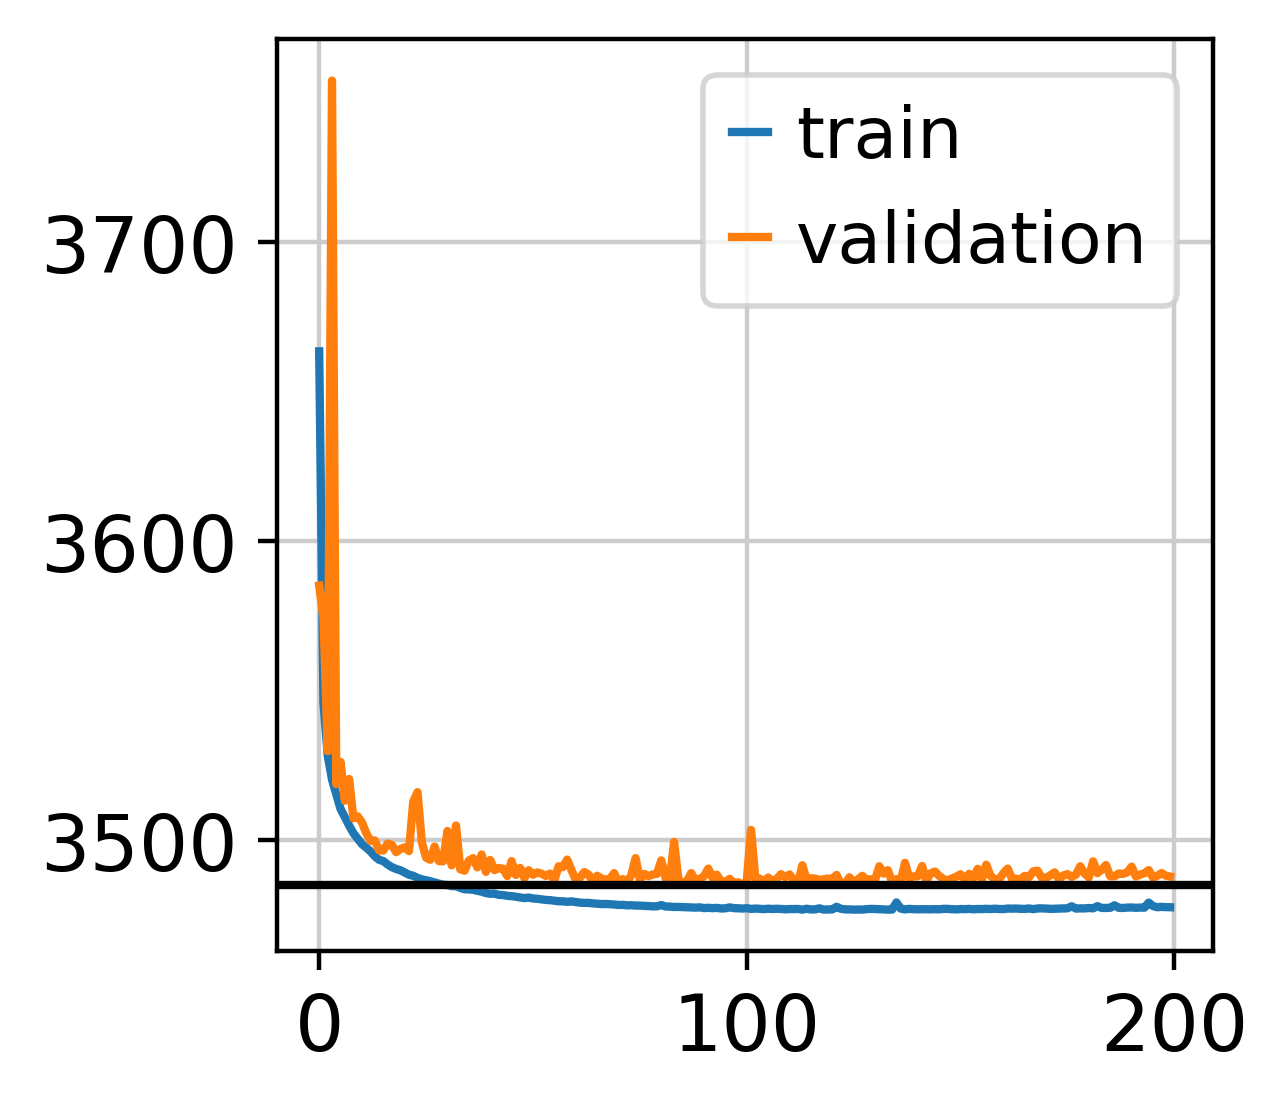

In [23]:
plt.plot(model.history['reconstruction_loss_train']['reconstruction_loss_train'], label='train')
plt.plot(model.history['reconstruction_loss_validation']['reconstruction_loss_validation'], label='validation')

plt.axhline(y, c = 'k')

plt.legend()
plt.show()

In [ ]:
adata.write_h5ad(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'temp_pbmc.h5ad'))
model.save('pbmc/pbmc_scvi_integration_model')
#adata = sc.read_h5ad(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'temp_pbmc.h5ad'))
#model = scvi.model.SCVI.load(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'pbmc_scvi_integration_model/'), adata)

INFO     File /media/MPEdge16/MM137/sc/py/py_out/pbmc/pbmc_scvi_integration_model/model.pt already downloaded      


/media/MPEdge16/miniconda_ns/lib/python3.9/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)


In [3]:
adata.obsm['X_scVI'] = model.get_latent_representation()
scvi_norm_count = model.get_normalized_expression(library_size = 1e4)
adata.layers['scvi_normalized'] = scvi_norm_count

In [4]:
sc.pp.neighbors(adata, use_rep = 'X_scVI', random_state = 123)

In [5]:
sc.tl.leiden(adata, resolution = 3, key_added = 'overcluster')

In [6]:
sc.tl.umap(adata)

In [ ]:
adata.write_h5ad(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'pbmc_int.h5ad'))

In [ ]:
sc.pl.umap(adata, color = 'lane', size = 1, legend_fontsize = 'medium')

In [ ]:
with rc_context({'figure.figsize': (4, 4)}):
    sc.pl.umap(adata, color = ['study_id', 'study_day'], size = 1, frameon = False)

In [ ]:
sc.set_figure_params(dpi=200)

sc.pl.umap(adata, color = ['CD3E','CD8A','CD79A','NKG7','CD14','FCGR3A','PF4','LYZ','TRAV1-2','TRGV9','MKI67','CD34','SELL','LEF1','BANK1','CD4'], size = 2, frameon = False, layer = 'scvi_normalized')

In [ ]:
plt.rcParams['figure.figsize'] = [7, 7]
sc.pl.umap(adata, color = ['JCHAIN','overcluster'], legend_loc = 'on data', size = 2, layer = 'scvi_normalized', legend_fontsize = 'small')

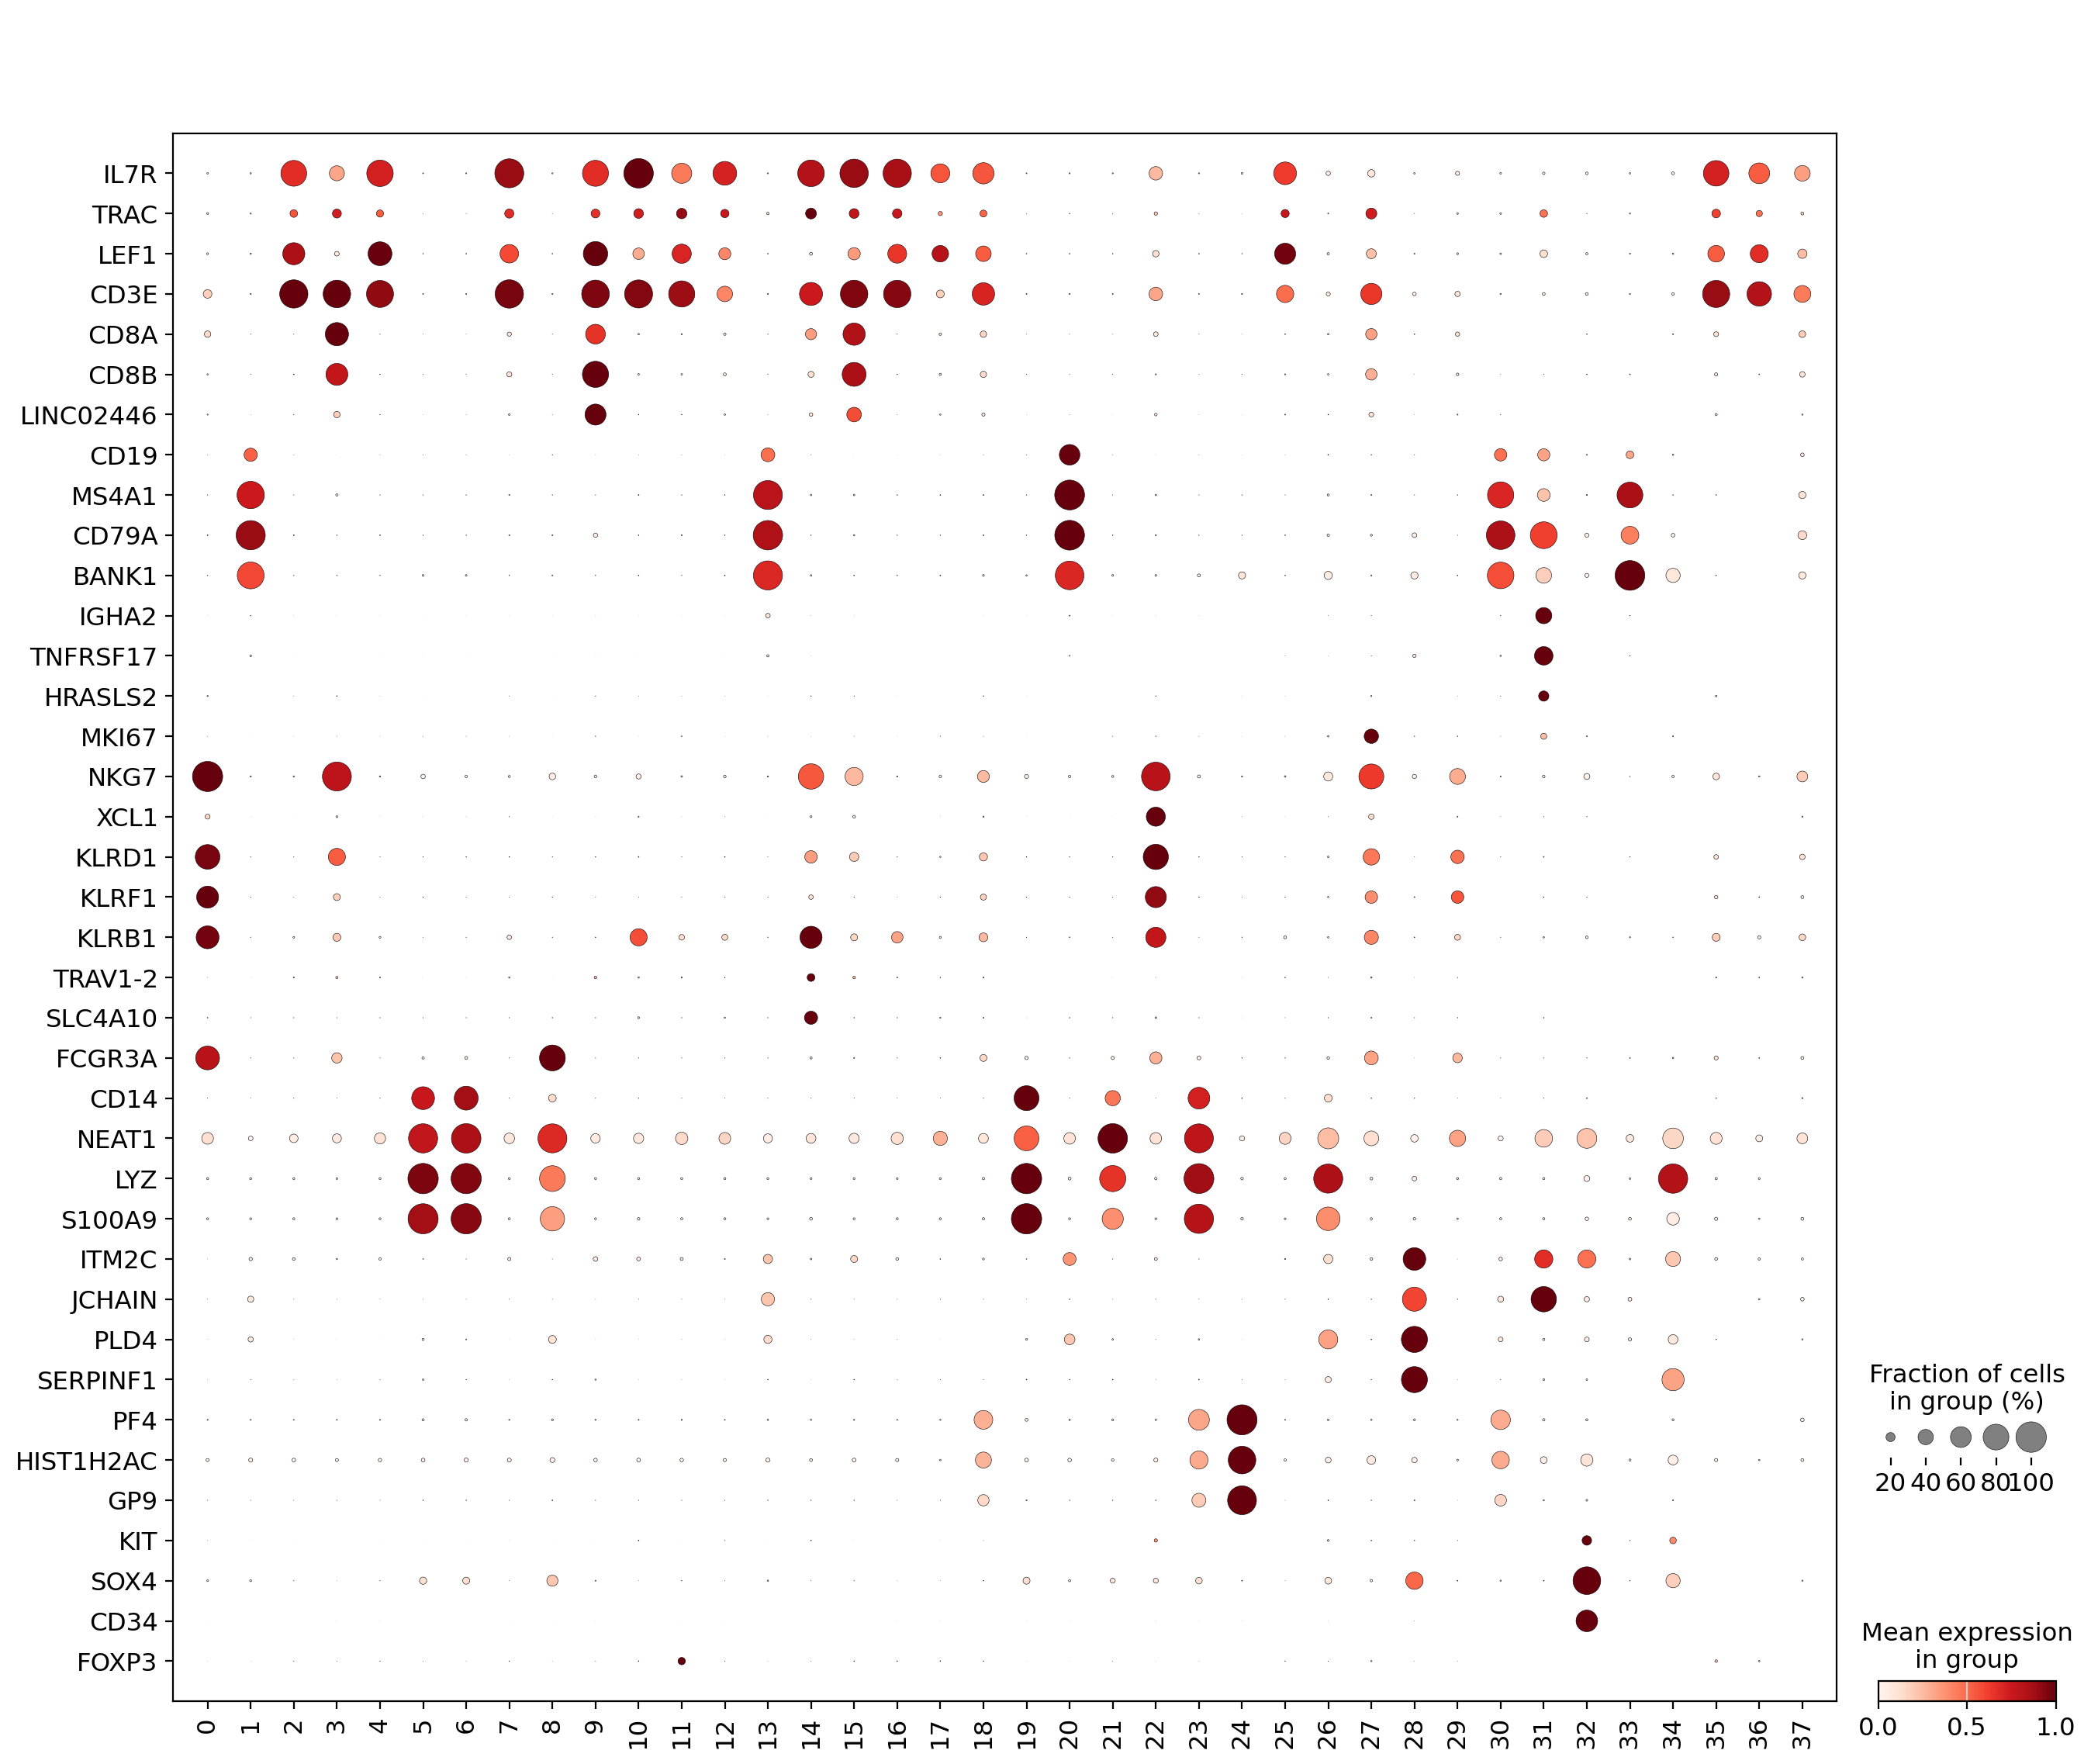

In [47]:
sc.set_figure_params(dpi=100)
sc.pl.dotplot(adata, ['IL7R', 'TRAC', 'LEF1', 'CD3E', 'CD8A', 'CD8B', 'LINC02446', 'CD19', 'MS4A1', 'CD79A', 'BANK1', 'IGHA2', 'TNFRSF17', 'HRASLS2', 'MKI67', 'NKG7', 'XCL1', 'KLRD1', 'KLRF1', 'KLRB1', 'TRAV1-2', 'SLC4A10', 'FCGR3A', 'CD14', 'NEAT1', 'LYZ', 'S100A9', 'ITM2C','JCHAIN','PLD4','SERPINF1', 'PF4', 'HIST1H2AC', 'GP9', 'KIT', 'SOX4','CD34','FOXP3'], groupby = 'overcluster', swap_axes = True,
              use_raw = True, standard_scale = 'var', dendrogram = False)

In [46]:
#uclus = max(adata.obs['overcluster'].astype(int))
#for i in range(uclus+1):
#    print("'" + str(i) + "'" + ": " + "'" + "',")

In [50]:
merge_type_ref = {
    '0': 'TNK',
    '1': 'B',
    '2': 'TNK',
    '3': 'TNK',
    '4': 'TNK',
    '5': 'Myeloid',
    '6': 'Myeloid',
    '7': 'TNK',
    '8': 'Myeloid',
    '9': 'TNK',
    '10': 'TNK',
    '11': 'TNK',
    '12': 'TNK',
    '13': 'B',
    '14': 'TNK',
    '15': 'TNK',
    '16': 'TNK',
    '17': 'TNK',
    '18': 'TNK',
    '19': 'Myeloid',
    '20': 'B',
    '21': 'Myeloid',
    '22': 'TNK',
    '23': 'Myeloid',
    '24': 'Platelet',
    '25': 'TNK',
    '26': 'Myeloid',
    '27': 'TNK',
    '28': 'Myeloid',
    '29': 'TNK',
    '30': 'B',
    '31': 'B',
    '32': 'HSPC',
    '33': 'B',
    '34': 'Myeloid',
    '35': 'TNK',
    '36': 'TNK',
    '37': 'TNK'
}

In [56]:
adata.obs['merged_type'] = adata.obs['overcluster'].map(merge_type_ref)
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,percent_mito,barcode_1,lane,solo_X,solo_doublet,solo_singlet,solo_prediction,study_id,study_day,barcode_2,n_genes,_scvi_batch,_scvi_labels,overcluster,merged_type
barcode_2,,,,,,,,,,,,,,,,,,
AAACCTGAGACCTAGG-1,SeuratProject,2581,1005,0.387447,AAACCTGAGACCTAGG-1,MM-1,AAACCTGAGACCTAGG-1,-2.222334,1.723653,singlet,Sadie-018,SD1,AAACCTGAGACCTAGG-1,1005,0,0,2,TNK
AAACCTGAGAGCCCAA-1,SeuratProject,1646,725,3.584447,AAACCTGAGAGCCCAA-1,MM-1,AAACCTGAGAGCCCAA-1,-5.264339,3.251961,singlet,Sadie-011,SD1,AAACCTGAGAGCCCAA-1,725,0,0,1,B
AAACCTGAGAGGTTGC-1,SeuratProject,4311,1966,3.757829,AAACCTGAGAGGTTGC-1,MM-1,AAACCTGAGAGGTTGC-1,-1.430171,0.703773,singlet,Sadie-011,SD1,AAACCTGAGAGGTTGC-1,1966,0,0,6,Myeloid
AAACCTGAGAGTCGGT-1,SeuratProject,1764,959,2.040816,AAACCTGAGAGTCGGT-1,MM-1,AAACCTGAGAGTCGGT-1,-3.245542,1.475645,singlet,Sadie-018,SD1,AAACCTGAGAGTCGGT-1,959,0,0,1,B
AAACCTGAGATATGGT-1,SeuratProject,3794,1828,2.424881,AAACCTGAGATATGGT-1,MM-1,AAACCTGAGATATGGT-1,-0.240121,-0.074265,singlet,Sadie-018,SD1,AAACCTGAGATATGGT-1,1828,0,0,7,TNK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTCATCGCATGGC-8,SeuratProject,4268,1818,2.085286,TTTGTCATCGCATGGC-1,MM-8,TTTGTCATCGCATGGC-1,-1.360806,1.416323,singlet,Sadie-016,SD2,TTTGTCATCGCATGGC-8,1818,7,0,6,Myeloid
TTTGTCATCGGTCCGA-8,SeuratProject,2495,1065,0.721443,TTTGTCATCGGTCCGA-1,MM-8,TTTGTCATCGGTCCGA-1,-2.775678,3.856038,singlet,Sadie-036,SD3,TTTGTCATCGGTCCGA-8,1065,7,0,4,TNK
TTTGTCATCTGATACG-8,SeuratProject,2782,1367,1.042416,TTTGTCATCTGATACG-1,MM-8,TTTGTCATCTGATACG-1,-2.887570,3.495042,singlet,Sadie-038,SD3,TTTGTCATCTGATACG-8,1367,7,0,0,TNK


In [ ]:
plt.rcParams['figure.figsize'] = [7, 7]
sc.pl.umap(adata, color = ['merged_type'], legend_loc = 'on data', size = 2, layer = 'scvi_normalized', legend_fontsize = 'small')

In [59]:
adata_tnk = adata[adata.obs['merged_type']=='TNK']
adata_b = adata[adata.obs['merged_type']=='B']
adata_myeloid = adata[adata.obs['merged_type']=='Myeloid']
adata_platelet = adata[adata.obs['merged_type']=='Platelet']
adata_hspc = adata[adata.obs['merged_type']=='HSPC']

In [60]:
adata_tnk.write_h5ad(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'pbmc_subset_tnk.h5ad'))
adata_b.write_h5ad(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'pbmc_subset_b.h5ad'))
adata_myeloid.write_h5ad(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'pbmc_subset_myeloid.h5ad'))
adata_platelet.write_h5ad(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'pbmc_subset_platelet.h5ad'))
adata_hspc.write_h5ad(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'pbmc_subset_hspc.h5ad'))

In [ ]:
rna_counts = adata_platelet.layers['counts']
adata_obs = adata_platelet.obs
adata_var = adata_platelet.var

mmwrite(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'anndata_elements/adata_pbmc_platelet_counts.mtx'), rna_counts)
adata_obs.to_csv(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'anndata_elements/adata_pbmc_platelet_obs.csv'))
adata_var.to_csv(str(REPO_ROOT / 'intermediate' / 'pbmc' / 'anndata_elements/adata_pbmc_platelet_var.csv'))